<a href="https://colab.research.google.com/github/Saiji/Data-Science-Work/blob/master/Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup and **Data Generation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create a sample dataset
np.random.seed(42)
data = {
    'tenure': np.random.randint(1, 72, 1000),
    'MonthlyCharges': np.random.uniform(20, 120, 1000),
    'TotalCharges': np.random.uniform(100, 8000, 1000),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], 1000),
    'Churn': np.random.choice(['Yes', 'No'], 1000, p=[0.2, 0.8])
}
df = pd.DataFrame(data)
df.head()

,tenure,MonthlyCharges,TotalCharges,Contract,Churn
0,52,105.569647,3271.805095,One year,No
1,15,103.021986,6420.560653,Month-to-month,Yes
2,61,59.718353,1711.881514,One year,No
3,21,86.808514,4485.171099,Two year,No
4,24,40.498430,5891.263239,One year,No


2. Preprocessing

In [2]:
# Encoding categorical 'Contract' and 'Churn'
le = LabelEncoder()
df['Contract'] = le.fit_transform(df['Contract'])
df['Churn'] = le.fit_transform(df['Churn']) # 1 for Yes, 0 for No

# Define Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical values for better performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

3. Model Training & Evaluation

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.97      0.86       155
           1       0.38      0.07      0.11        45

    accuracy                           0.77       200
   macro avg       0.58      0.52      0.49       200
weighted avg       0.69      0.77      0.70       200



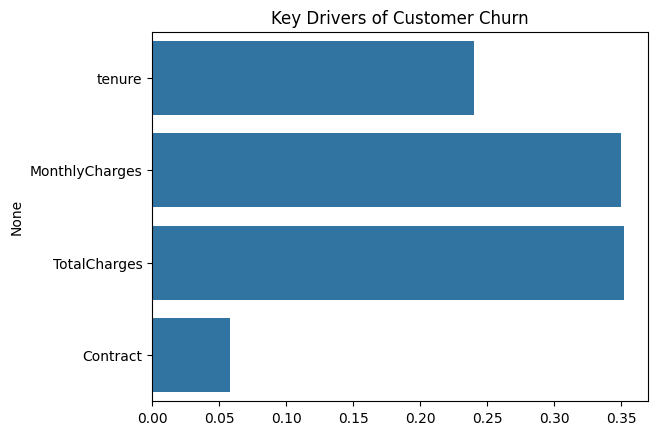

In [3]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Print Results
print("--- Classification Report ---")
print(classification_report(y_test, predictions))

# Visualize Feature Importance
importances = model.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features)
plt.title('Key Drivers of Customer Churn')
plt.show()